# 検索性能の評価

## TF-IDF

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from ranking_eval import load_from_json, RankingEvaluator
#import recall_eval
from tqdm.notebook import tqdm_notebook
from janome.tokenizer import Tokenizer
from sklearn.metrics import auc
import json

t = Tokenizer()

def split_text_only_noun(text):
    words = []
    for c in t.tokenize(text):
        part_of_speech = c.part_of_speech.split(',')[0]
        if part_of_speech in ["名詞"]:
            # print(c.surface) # c.base_form
            words.append(c.surface)
    return words


# TF-IDFベクトル化
def tfidf_vectorize(corpus):
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(corpus)
    return tfidf_matrix, vectorizer

def tfidf_vectorize2(bags):
    tfidf = TfidfTransformer(use_idf=True, norm='l2', smooth_idf=True)
    tf_idf = tfidf.fit_transform(bags)
    return tfidf, tf_idf

# 文書検索
def search(query, tfidf_matrix, vectorizer):
    query_vec = vectorizer.transform([query])
    cosine_similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    return cosine_similarities.argsort()[::-1]  # 降順でインデックスを返す

def search2(query, tfidf_matrix, vectorizer: TfidfTransformer):
    query_vec = vectorizer.transform(query)
    cosine_similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    return cosine_similarities.argsort()[::-1]  # 降順でインデックスを返す
# Recall@kの計算
def recall_at_k(true_indices, ranked_indices, k):
    top_k = set(ranked_indices[:k])
    relevant_docs = set(true_indices)
    return len(relevant_docs.intersection(top_k)) / len(relevant_docs)

# Precision@kの計算
def precision_at_k(true_indices, ranked_indices, k):
    top_k = set(ranked_indices[:k])
    relevant_docs = set(true_indices)
    return len(relevant_docs.intersection(top_k)) / len(top_k)

# PR曲線の点とAUCを計算する関数
def calculate_pr_curve_and_auc(true_indices, ranked_indices):
    precision_values = []
    recall_values = []
    
    # 各kに対してprecisionとrecallを計算
    for k in range(1, len(ranked_indices) + 1):
        precision = precision_at_k(true_indices, ranked_indices, k)
        recall = recall_at_k(true_indices, ranked_indices, k)
        # print(precision, recall)
        precision_values.append(precision)
        recall_values.append(recall)
    
    # AUCの計算
    pr_auc = auc(recall_values, precision_values)

    # 結果を辞書に格納
    pr_curve_data = {
        "precision": precision_values,
        "recall": recall_values,
        "auc": pr_auc
    }

    return pr_curve_data

# 各クエリにおける平均精度を計算
def average_precision(true_indices, ranked_indices):
    ap_sum = 0
    hit_count = 0
    for k, index in enumerate(ranked_indices, start=1):
        if index in true_indices:
            hit_count += 1
            ap_sum += hit_count / k
    if hit_count == 0:
        return 0
    return ap_sum / len(true_indices)

# MAPを計算する関数
def calculate_map(scores_dict):
    ap_values = [score['average_precision'] for score in scores_dict.values()]
    return sum(ap_values) / len(ap_values) if ap_values else 0

def create_stopwords(file_path):
    stop_words = []
    return stop_words
    for w in open(path, 'r', encoding='utf8'):
        w = w.replace('\n', '')
        if len(w) > 0:
            stop_words.append(w)
    return stop_words    

path = "stop_words.txt"
stop_words = create_stopwords(path)

# 独自定義ストップワード
stop_words.extend(',|せる|する'.split('|'))
stop_words.extend([chr(i) for i in range(ord('ぁ'), ord('ん') + 1)]) # ひらがな1文字

corpus, true_idxes_dict = load_from_json(
    "../../resources/dataset/ranking_eval/sho_ranking.json"
)

#corpus, true_idxes_dict = recall_eval.load_from_json("../resources/dataset/ranking_eval/sho_ranking.json")

max_k = len(corpus)

from sklearn.feature_extraction.text import CountVectorizer

words_list = []
for text in corpus:
    words = split_text_only_noun(text)
    clean_words = []
    for w in words:
        if not w in stop_words:
            clean_words.append(w)
    words_list.append(clean_words)

docs = [' '.join(words) for words in words_list]
count = CountVectorizer(token_pattern='(?u)\\b\\w+\\b') # token_pattern -> 一文字除外回避

bags = count.fit_transform(docs) # どの単語が含まれているか

all_score = {}
vectorizer, tfidf_matrix  = tfidf_vectorize2(bags)

for query, true_idx_list in true_idxes_dict.items():
    q_bags = count.transform([query])
    ranked_indices = search2(q_bags, tfidf_matrix, vectorizer)
    score = calculate_pr_curve_and_auc(true_idx_list, ranked_indices)
    score['average_precision'] = average_precision(true_idx_list, ranked_indices)
    all_score[query] = score

map_score = calculate_map(all_score)
print(f"MAP Score: {map_score}")

import json
with open("tf_idf_score.json", mode="w", encoding="utf-8") as fp:
    json.dump(all_score, fp, ensure_ascii=False)

MAP Score: 0.564358676268221


## 太田さんのWord2Vec

In [9]:
from gensim.models import KeyedVectors
from ranking_eval import load_from_json
from janome.tokenizer import Tokenizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import auc
import numpy as np
import json



#model = KeyedVectors.load_word2vec_format('../resources/model/tmword2vec.model', binary=False)
from gensim.models import KeyedVectors

model = KeyedVectors.load_word2vec_format(
    "../resources/model/tmword2vec.model",
    binary=False,
    encoding="utf-8"
)



ccorpus, true_idxes_dict = load_from_json(
    "../../resources/dataset/ranking_eval/sho_ranking.json"
)

t = Tokenizer()

def sentence_to_vec(sentence, model):
    vecs = []
    for token in t.tokenize(sentence):
        if token.surface in model:
            vecs.append(model[token.surface])
    if len(vecs) == 0:
        return None
    return np.mean(vecs, axis=0)

corpus_vecs = []
valid_indices = []

for i, text in enumerate(corpus):
    v = sentence_to_vec(text, model)
    if v is not None:
        corpus_vecs.append(v)
        valid_indices.append(i)

corpus_vecs = np.array(corpus_vecs)


# 文書検索
"""
def search(query, corpus):
    query_vec = model[query]
    corpus_vec = [model[word] for word in corpus]
    print(type(query_vec), query_vec.shape)
    print(type(corpus_vec), corpus_vec[0].shape)

    cosine_similarities = cosine_similarity([query_vec], corpus_vec).flatten()
    return cosine_similarities.argsort()[::-1]  # 降順でインデックスを返す"""

def search(query, corpus_vecs, valid_indices):
    q_vec = sentence_to_vec(query, model)
    if q_vec is None:
        return []

    sims = cosine_similarity([q_vec], corpus_vecs)[0]
    ranked = sims.argsort()[::-1]
    return [valid_indices[i] for i in ranked]


# Recall@kの計算
def recall_at_k(true_indices, ranked_indices, k):
    top_k = set(ranked_indices[:k])
    relevant_docs = set(true_indices)
    if len(relevant_docs) != len(true_indices):
        print("Error recall")
    return len(relevant_docs.intersection(top_k)) / len(relevant_docs)

# Precision@kの計算
def precision_at_k(true_indices, ranked_indices, k):
    top_k = set(ranked_indices[:k])
    if len(top_k) != len(ranked_indices[:k]):
        print("Error presicion")
    relevant_docs = set(true_indices)
    return len(relevant_docs.intersection(top_k)) / len(top_k)

# PR曲線の点とAUCを計算する関数
def calculate_pr_curve_and_auc(true_indices, ranked_indices):
    precision_values = []
    recall_values = []
    print(f"{len(true_indices)} {sorted(list(true_indices))}")
    print(f"{len(ranked_indices)} {ranked_indices}")
    # 各kに対してprecisionとrecallを計算
    for k in range(1, len(ranked_indices) + 1):
        precision = precision_at_k(true_indices, ranked_indices, k)
        recall = recall_at_k(true_indices, ranked_indices, k)
        # print(precision, recall)
        precision_values.append(precision)
        recall_values.append(recall)
    
    # AUCの計算
    pr_auc = auc(recall_values, precision_values)

    # 結果を辞書に格納
    pr_curve_data = {
        "precision": precision_values,
        "recall": recall_values,
        "auc": pr_auc
    }

    return pr_curve_data

# 各クエリにおける平均精度を計算
def average_precision(true_indices, ranked_indices):
    ap_sum = 0
    hit_count = 0
    for k, index in enumerate(ranked_indices, start=1):
        if index in true_indices:
            hit_count += 1
            ap_sum += hit_count / k
    if hit_count == 0:
        return 0
    return ap_sum / len(true_indices)

# MAPを計算する関数
def calculate_map(scores_dict):
    ap_values = [score['average_precision'] for score in scores_dict.values()]
    return sum(ap_values) / len(ap_values) if ap_values else 0

all_score = {}
max_k = len(corpus)

"""for query, true_idx_list in true_idxes_dict.items():
    ranked_indices = search(query, corpus)
    score = calculate_pr_curve_and_auc(true_idx_list, ranked_indices)
    score['average_precision'] = average_precision(true_idx_list, ranked_indices)
    all_score[query] = score"""

for query, true_idx_list in true_idxes_dict.items():
    ranked_indices = search(query, corpus_vecs, valid_indices)

    score = calculate_pr_curve_and_auc(true_idx_list, ranked_indices)
    score["average_precision"] = average_precision(true_idx_list, ranked_indices)

    all_score[query] = score


map_score = calculate_map(all_score)
print(f"MAP Score: {map_score}")

import json
"""with open("word2vec_score.json", mode="w", encoding="utf-8") as fp:
    json.dump(all_score, fp, ensure_ascii=False)"""
with open("word2vec_score.json", "w", encoding="utf-8") as f:
    json.dump(all_score, f, ensure_ascii=False)


24 [0, 1, 29, 30, 32, 35, 38, 39, 40, 41, 42, 46, 50, 51, 52, 53, 55, 56, 63, 64, 65, 68, 73, 74]
75 [65, 55, 53, 43, 51, 74, 56, 39, 30, 52, 14, 42, 0, 40, 29, 61, 50, 64, 25, 66, 35, 67, 19, 27, 47, 23, 33, 68, 63, 20, 21, 32, 24, 38, 48, 17, 58, 18, 22, 70, 62, 15, 49, 46, 54, 8, 13, 6, 34, 12, 45, 7, 71, 28, 26, 69, 60, 5, 16, 31, 41, 4, 57, 1, 59, 10, 73, 72, 44, 11, 9, 3, 2, 37, 36]
10 [8, 18, 19, 20, 21, 27, 43, 55, 56, 66]
75 [55, 56, 53, 74, 51, 43, 65, 39, 47, 35, 64, 40, 66, 30, 62, 70, 19, 42, 14, 27, 21, 52, 24, 61, 23, 25, 20, 71, 18, 17, 0, 68, 50, 12, 48, 29, 49, 6, 33, 22, 38, 67, 34, 4, 8, 69, 13, 54, 58, 7, 32, 26, 57, 45, 11, 16, 63, 31, 41, 15, 1, 5, 72, 73, 3, 10, 44, 60, 28, 9, 46, 37, 59, 2, 36]
2 [17, 55]
75 [55, 56, 53, 43, 74, 65, 51, 39, 40, 66, 47, 14, 42, 52, 35, 64, 19, 27, 62, 30, 25, 34, 61, 67, 12, 33, 71, 21, 0, 20, 50, 29, 24, 17, 18, 70, 58, 38, 4, 48, 23, 68, 45, 16, 63, 54, 32, 15, 26, 8, 22, 7, 1, 57, 6, 69, 73, 49, 28, 13, 44, 31, 41, 9, 3, 5, 6

## Sentence-BERT

TF-IDFやWord2Vecなどの結果も含めています

In [ ]:
from ranking_eval import RankingEvaluator
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, models
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers import models, losses, datasets
import json
import os

ranking_hyoka_dataset = "../../resources/dataset/ranking_eval/sho_ranking.json"
dir = "./eval_result/"

model_path_list = [
    ["../bert_finetune/jmedroberta_livedoor/run-9"],
    ["../bert_finetune/jmedroberta_tmclinical/run-9"],
    ["../bert_finetune/jmedroberta_tmnormal/run-9"]
]

#model_path_list.sort(reverse=True, key=lambda x: x[1])

with open("./word2vec_score.json", mode="r", encoding="utf-8") as fp:
    w2v_score = json.load(fp)

with open("./tf_idf_score.json", mode="r", encoding="utf-8") as fp:
    tfidf_score = json.load(fp)

def calculate_map(scores_dict):
    ap_values = [score['average_precision'] for score in scores_dict.values()]
    return sum(ap_values) / len(ap_values) if ap_values else 0

score_dict = {}
evaluator = RankingEvaluator(ranking_hyoka_dataset)

for i in range(len(model_path_list)):
    model_path = model_path_list[i][0]
    word_embedding_model = models.Transformer(model_path)
    pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension(),
                                pooling_mode_mean_tokens=True,
                                pooling_mode_cls_token=False,
                                pooling_mode_max_tokens=False)

    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
    score = evaluator.run_eval(model, output_path=model_path.replace(".", "").replace("/", ""))
    itemnum = 0
    average_num = 0.0
    auc_dict = {}
    print(f"{model_path}: {calculate_map(score)}")
    for q, v in score.items():
        itemnum = itemnum + 1
        average_num = average_num + v['auc']
        auc_dict[q] = v['auc']
    average_num /= itemnum
    model_path_list[i].append(average_num)
    model_path_list[i].append(auc_dict)
    score_dict[model_path] = score


baseline_scores = [(w2v_score, "word2vec"), (tfidf_score, "tf-idf")]

for score, name in baseline_scores:
    itemnum = 0
    average_num = 0.0
    auc_dict = {}
    for q, v in score.items():
        itemnum = itemnum + 1
        average_num = average_num + v['auc']
        auc_dict[q] = v['auc']
    average_num /= itemnum
    print(f"{name} mean auc: {average_num}")


score_dict["word2vec"] = w2v_score
score_dict["tf-idf"] = tfidf_score

name = "all"
# save_graph(score_dict, dir, name)

with open(f"{os.path.join(dir, name)}.json", mode="w", encoding="utf-8") as fp:
    json.dump(score_dict, fp, ensure_ascii=False)


"""model_path_list.sort(reverse=True, key=lambda x: x[2])
for item in model_path_list:
    print(item)"""

model_path_list = [x for x in model_path_list if len(x) >= 2]

model_path_list.sort(key=lambda x: x[1], reverse=True)

for item in model_path_list:
    print(f"model={item[0]}, mean_auc={item[1]}")


with open(f"{os.path.join(dir, name)}_score_list.json", mode="w", encoding="utf-8") as fp:
    json.dump(model_path_list, fp, ensure_ascii=False)

../bert_finetune/jmedroberta_livedoor/run-9: 0.26293104419994706
../bert_finetune/jmedroberta_tmclinical/run-9: 0.3634030633071217
../bert_finetune/jmedroberta_tmnormal/run-9: 0.29111201558656546
word2vec mean auc: 0.3719494978721375
tf-idf mean auc: 0.5061301374964284
model=../bert_finetune/jmedroberta_tmclinical/run-9, mean_auc=0.3076532112050026
model=../bert_finetune/jmedroberta_tmnormal/run-9, mean_auc=0.24441710930786992
model=../bert_finetune/jmedroberta_livedoor/run-9, mean_auc=0.23774498771692004


In [10]:
import json
import torch
import numpy as np
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

def average_precision(ranked_ids, positive_ids):
    hit = 0
    score = 0.0

    for i, doc_id in enumerate(ranked_ids, start=1):
        if doc_id in positive_ids:
            hit += 1
            score += hit / i

    if hit == 0:
        return 0.0
    return score / len(positive_ids)

with open("../../resources/dataset/ranking_eval/sho_ranking.json", "r", encoding="utf-8") as f:
    data = json.load(f)

sho_ids = []
sho_texts = []

for symptom, entry in data.items():
    for s in entry["positive"] + entry["negative"]:
        if s["uuid"] not in sho_ids:
            sho_ids.append(s["uuid"])
            sho_texts.append(
                s["name"] + "。" + s["description"] + "。" + s["symptom"]
            )

model = SentenceTransformer("../bert_preprocess/jmedroberta_bf_randinit")

sho_embs = model.encode(
    sho_texts,
    convert_to_tensor=True,
    show_progress_bar=True
)

APs = {}

for symptom, entry in data.items():
    query_emb = model.encode(symptom, convert_to_tensor=True)

    scores = cos_sim(query_emb, sho_embs)[0]
    ranking = torch.argsort(scores, descending=True)

    ranked_ids = [sho_ids[i] for i in ranking.tolist()]
    positive_ids = {s["uuid"] for s in entry["positive"]}

    ap = average_precision(ranked_ids, positive_ids)
    APs[symptom] = ap

    print(f"{symptom}: AP={ap:.4f}")

MAP = np.mean(list(APs.values()))
print(f"\nMAP = {MAP:.4f}")






No sentence-transformers model found with name ../bert_preprocess/jmedroberta_bf_randinit. Creating a new one with mean pooling.
Batches: 100%|██████████| 3/3 [00:00<00:00, 26.97it/s]

発熱: AP=0.7176
浮腫: AP=0.5157
出血: AP=0.1156
いらいら: AP=0.4478
不眠: AP=0.4448

MAP = 0.4483


表の作成

In [ ]:
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, models
from sentence_transformers.util import cos_sim

def get_ranking(model, query, corpus):
    query_emb = model.encode(query, convert_to_tensor=True)
    corpus_emb = model.encode(corpus, convert_to_tensor=True)
    scores = cos_sim(query_emb, corpus_emb)[0]
    ranking = torch.argsort(scores, descending=True).cpu().tolist()
    return ranking

def recall_at_k(ranking, true_indices, k):
    return 1.0 if any(idx in true_indices for idx in ranking[:k]) else 0.0

def average_precision(ranking, true_indices):
    hit = 0
    score = 0.0
    for i, idx in enumerate(ranking, start=1):
        if idx in true_indices:
            hit += 1
            score += hit / i
    return score / len(true_indices) if true_indices else 0.0

def make_ap_map_table(model, evaluator):
    rows = {}

    for symptom, true_indices in evaluator.true_idxes_dict.items():
        query = symptom.replace("・", "&")
        ranking = get_ranking(model, query, evaluator.corpus)
        ap = average_precision(ranking, true_indices)
        rows[symptom] = ap

    df = pd.DataFrame(rows, index=["AP"]).T
    df["AP"] = df["AP"].round(2)

    map_score = df["AP"].mean()
    df.loc["MAP"] = map_score

    return df

def make_recall_table(model, evaluator, k):
    rows = {}

    for symptom, true_indices in evaluator.true_idxes_dict.items():
        query = symptom.replace("・", "&")
        ranking = get_ranking(model, query, evaluator.corpus)
        rows[symptom] = recall_at_k(ranking, true_indices, k)

    df = pd.DataFrame.from_dict(rows, orient="index", columns=[f"R@{k}"])
    return df

model_path = "../sbert_train/jmedroberta_mnr_hn"

word_embedding_model = models.Transformer(model_path)
pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True,
    pooling_mode_cls_token=False,
    pooling_mode_max_tokens=False,
)
model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# AP / MAP 表
ap_map_df = make_ap_map_table(model, evaluator)
display(ap_map_df)

# Recall 表
r1_df  = make_recall_table(model, evaluator, k=1)
r5_df  = make_recall_table(model, evaluator, k=5)
r10_df = make_recall_table(model, evaluator, k=10)

display(r1_df)
display(r5_df)
display(r10_df)

def evaluate_models(model_paths, evaluator):
    ap_tables = []
    r1_tables = []
    r5_tables = []
    r10_tables = []

    for path in model_paths:
        print(f"Evaluating {path}")

        word_embedding_model = models.Transformer(path)
        pooling_model = models.Pooling(
            word_embedding_model.get_word_embedding_dimension(),
            pooling_mode_mean_tokens=True,
            pooling_mode_cls_token=False,
            pooling_mode_max_tokens=False,
        )
        model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

        ap_df = make_ap_map_table(model, evaluator)
        ap_df.columns = [path]
        ap_tables.append(ap_df)

        r1_tables.append(make_recall_table(model, evaluator, 1).rename(columns={"R@1": path}))
        r5_tables.append(make_recall_table(model, evaluator, 5).rename(columns={"R@5": path}))
        r10_tables.append(make_recall_table(model, evaluator, 10).rename(columns={"R@10": path}))

    return (
        pd.concat(ap_tables, axis=1),
        pd.concat(r1_tables, axis=1),
        pd.concat(r5_tables, axis=1),
        pd.concat(r10_tables, axis=1),
    )

ap_table, r1_table, r5_table, r10_table = evaluate_models(model_paths, evaluator)

display(ap_table)
display(r1_table)
display(r5_table)
display(r10_table)





,AP
発熱,0.730
浮腫,0.630
出血,0.070
いらいら,0.620
不眠,0.820
MAP,0.574


NameError: name 'make_recall_table' is not defined

In [11]:
from sentence_transformers.util import cos_sim
import numpy as np

def get_ranking(model, query, corpus_texts):
    query_emb = model.encode(query, convert_to_tensor=True)
    corpus_emb = model.encode(corpus_texts, convert_to_tensor=True)
    scores = cos_sim(query_emb, corpus_emb)[0]
    ranking = torch.argsort(scores, descending=True).cpu().tolist()
    return ranking

def recall_at_k_for_query(ranking, true_indices, k):
    return 1.0 if any(idx in true_indices for idx in ranking[:k]) else 0.0

recall_results = {}

for symptom in evaluator.symptom_list:
    query = symptom.replace("・", "&")  # SBERT用
    ranking = get_ranking(model, query, evaluator.corpus_texts)
    true_indices = evaluator.true_idxes_dict[symptom]

    recall_results[symptom] = {
        "R@1": recall_at_k_for_query(ranking, true_indices, 1),
        "R@5": recall_at_k_for_query(ranking, true_indices, 5),
        "R@10": recall_at_k_for_query(ranking, true_indices, 10),
    }

mean_r1 = np.mean([v["R@1"] for v in recall_results.values()])
mean_r5 = np.mean([v["R@5"] for v in recall_results.values()])
mean_r10 = np.mean([v["R@10"] for v in recall_results.values()])


AttributeError: 'RankingEvaluator' object has no attribute 'symptom_list'

In [2]:
from ranking_eval import RankingEvaluator
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, models
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers import models, losses, datasets
import json
import os

ranking_hyoka_dataset = "../../resources/dataset/ranking_eval/sho_ranking.json"
dir = "./eval_result/"

model_path_list = [
    ["../bert_finetune/jmedroberta_livedoor/run-9"],
    ["../bert_finetune/jmedroberta_tmclinical/run-9"],
    ["../bert_finetune/jmedroberta_tmnormal/run-9"],
    ["../sbert_train/jmedroberta_mnr_hn"],
    ["../sbert_train/jmedroberta_mnr_sn"]
]

#model_path_list.sort(reverse=True, key=lambda x: x[1])

with open("./word2vec_score.json", mode="r", encoding="utf-8") as fp:
    w2v_score = json.load(fp)

with open("./tf_idf_score.json", mode="r", encoding="utf-8") as fp:
    tfidf_score = json.load(fp)

def calculate_recall_at_k(score_dict, k):
    hit = 0
    total = 0

    for q, v in score_dict.items():
        ranking = v["ranking"]
        topk = ranking[:k]

        if any(item["label"] == 1 for item in topk):
            hit += 1
        total += 1

    return hit / total if total > 0 else 0.0


def calculate_mrr(score_dict):
    rr_sum = 0.0
    total = 0

    for q, v in score_dict.items():
        ranking = v["ranking"]
        for i, item in enumerate(ranking, start=1):
            if item["label"] == 1:
                rr_sum += 1.0 / i
                break
        total += 1

    return rr_sum / total if total > 0 else 0.0

def calculate_map(scores_dict):
    ap_values = [score['average_precision'] for score in scores_dict.values()]
    return sum(ap_values) / len(ap_values) if ap_values else 0

score_dict = {}
evaluator = RankingEvaluator(ranking_hyoka_dataset)

for i in range(len(model_path_list)):
    model_path = model_path_list[i][0]
    word_embedding_model = models.Transformer(model_path)
    pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension(),
                                pooling_mode_mean_tokens=True,
                                pooling_mode_cls_token=False,
                                pooling_mode_max_tokens=False)

    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
    score = evaluator.run_eval(model, output_path=model_path.replace(".", "").replace("/", ""))
    itemnum = 0
    average_num = 0.0
    auc_dict = {}
    print(f"{model_path}: {calculate_map(score)}")
    for q, v in score.items():
        itemnum = itemnum + 1
        average_num = average_num + v['auc']
        auc_dict[q] = v['auc']
    average_num /= itemnum
    model_path_list[i].append(average_num)
    model_path_list[i].append(auc_dict)
    score_dict[model_path] = score

        # ===== 追加評価 =====

    recall_1  = calculate_recall_at_k(score, k=1)
    recall_5  = calculate_recall_at_k(score, k=5)
    recall_10 = calculate_recall_at_k(score, k=10)
    mrr = calculate_mrr(score)

    model_path_list[i].append({
        "R@1": recall_1,
        "R@5": recall_5,
        "R@10": recall_10,
        "MRR": mrr
    })

    print(
        f"{model_path} | "
        f"MAP={calculate_map(score):.4f}, "
        f"MRR={mrr:.4f}, "
        f"R@1={recall_1:.4f}, "
        f"R@5={recall_5:.4f}, "
        f"R@10={recall_10:.4f}"
    )



baseline_scores = [(w2v_score, "word2vec"), (tfidf_score, "tf-idf")]

for score, name in baseline_scores:
    itemnum = 0
    average_num = 0.0
    auc_dict = {}
    recall_1  = calculate_recall_at_k(score, k=1)
    recall_5  = calculate_recall_at_k(score, k=5)
    recall_10 = calculate_recall_at_k(score, k=10)
    mrr = calculate_mrr(score)

    print(
        f"{name} | "
        f"MRR={mrr:.4f}, "
        f"R@1={recall_1:.4f}, "
        f"R@5={recall_5:.4f}, "
        f"R@10={recall_10:.4f}"
    )
    for q, v in score.items():
        itemnum = itemnum + 1
        average_num = average_num + v['auc']
        auc_dict[q] = v['auc']
    average_num /= itemnum
    print(f"{name} mean auc: {average_num}")


score_dict["word2vec"] = w2v_score
score_dict["tf-idf"] = tfidf_score

name = "all"
# save_graph(score_dict, dir, name)

with open(f"{os.path.join(dir, name)}.json", mode="w", encoding="utf-8") as fp:
    json.dump(score_dict, fp, ensure_ascii=False)


"""model_path_list.sort(reverse=True, key=lambda x: x[2])
for item in model_path_list:
    print(item)"""

model_path_list = [x for x in model_path_list if len(x) >= 2]

model_path_list.sort(key=lambda x: x[1], reverse=True)

for item in model_path_list:
    print(f"model={item[0]}, mean_auc={item[1]}")


with open(f"{os.path.join(dir, name)}_score_list.json", mode="w", encoding="utf-8") as fp:
    json.dump(model_path_list, fp, ensure_ascii=False)



TypeError: RankingEvaluator.run_eval() got an unexpected keyword argument 'output_path'

In [2]:
q, v = next(iter(score.items()))
print(v.keys())
print(v)


dict_keys(['precision', 'recall', 'auc', 'average_precision'])
{'precision': [1.0, 0.5, 0.6666666666666666, 0.75, 0.8, 0.8333333333333334, 0.8571428571428571, 0.875, 0.8888888888888888, 0.8, 0.7272727272727273, 0.6666666666666666, 0.6923076923076923, 0.7142857142857143, 0.6666666666666666, 0.6875, 0.7058823529411765, 0.6666666666666666, 0.6842105263157895, 0.7, 0.7142857142857143, 0.7272727272727273, 0.7391304347826086, 0.75, 0.72, 0.6923076923076923, 0.7037037037037037, 0.6785714285714286, 0.6551724137931034, 0.6333333333333333, 0.6451612903225806, 0.625, 0.6060606060606061, 0.5882352941176471, 0.5714285714285714, 0.5555555555555556, 0.5405405405405406, 0.5263157894736842, 0.5128205128205128, 0.5, 0.4878048780487805, 0.47619047619047616, 0.46511627906976744, 0.45454545454545453, 0.4444444444444444, 0.43478260869565216, 0.425531914893617, 0.4166666666666667, 0.40816326530612246, 0.42, 0.4117647058823529, 0.40384615384615385, 0.39622641509433965, 0.3888888888888889, 0.38181818181818183,

In [8]:
model_path = ["../sbert_train/jmedroberta_mnr_hn"]
def recall_at_k_from_pr(score_dict, k):
    recalls = []
    for q, v in score_dict.items():
        recall_curve = v["recall"]
        if len(recall_curve) >= k:
            recalls.append(recall_curve[k-1])
        else:
            recalls.append(recall_curve[-1])
    return sum(recalls) / len(recalls)

#mean_auc = score["auc"]

r1  = recall_at_k_from_pr(score, 1)
r5  = recall_at_k_from_pr(score, 5)
r10 = recall_at_k_from_pr(score, 10)

print(
    f"{model_path}: "
    #f"mean_auc={mean_auc:.4f}, "
    f"R@1={r1:.4f}, "
    f"R@5={r5:.4f}, "
    f"R@10={r10:.4f}"
)



['../sbert_train/jmedroberta_mnr_hn']: R@1=0.0083, R@5=0.0583, R@10=0.1292


In [5]:
import torch
from sentence_transformers import SentenceTransformer, models
from sentence_transformers.util import cos_sim
import numpy as np

#print(next(iter(score.values())).keys())

# ===== 設定 =====
hyoka_data_path = "../../resources/dataset/ranking_eval/sho_ranking.json"  # 評価用JSON
model_paths = [
    "../sbert_train/jmedroberta_mnr_hn",
    "../sbert_train/jmedroberta_mnr_sn"
]


steps_per_epoch = 9216

# ===== Recall@k 計算関数 =====
def calculate_recall_at_k(score_dict, k):
    hit = 0
    total = 0

    for q, v in score_dict.items():
        ranking = v["ranking"]
        true_indices = evaluator.true_idxes_dict[q]

        # 上位kに正解が1つでも含まれるか
        if any(idx in true_indices for idx in ranking[:k]):
            hit += 1
        total += 1

    return hit / total if total > 0 else 0.0


evaluator = RankingEvaluator(hyoka_data_path)

results = []

for model_path in model_paths:
    print(f"\nEvaluating: {model_path}")

    word_embedding_model = models.Transformer(model_path)
    pooling_model = models.Pooling(
        word_embedding_model.get_word_embedding_dimension(),
        pooling_mode_mean_tokens=True,
        pooling_mode_cls_token=False,
        pooling_mode_max_tokens=False,
    )

    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

    score = evaluator.run_eval(model)

    # mean AUC
    mean_auc = np.mean([v["auc"] for v in score.values()])

    # Recall@k
    r1  = calculate_recall_at_k(score, k=1)
    r5  = calculate_recall_at_k(score, k=5)
    r10 = calculate_recall_at_k(score, k=10)

    print(
        f"mean_auc={mean_auc:.4f}, "
        f"R@1={r1:.4f}, "
        f"R@5={r5:.4f}, "
        f"R@10={r10:.4f}"
    )

    results.append({
        "model": model_path,
        "mean_auc": mean_auc,
        "R@1": r1,
        "R@5": r5,
        "R@10": r10
    })




Evaluating: ../sbert_train/jmedroberta_mnr_hn


Batches: 100%|██████████| 3/3 [00:00<00:00, 53.03it/s]


mean_auc=0.5059, R@1=0.8000, R@5=0.8000, R@10=0.8000

Evaluating: ../sbert_train/jmedroberta_mnr_sn


Batches: 100%|██████████| 3/3 [00:00<00:00, 52.88it/s]


mean_auc=0.6182, R@1=0.8000, R@5=0.8000, R@10=1.0000


In [9]:
for q, v in score.items():
    print(q, sum(item["label"] == 1 for item in v["ranking"]))
    break


KeyError: 'ranking'

In [9]:
import os
import re

base_model_dir = "../sbert_train/jmedroberta_mnr_hn_20_c"

checkpoints = []
for d in os.listdir(base_model_dir):
    m = re.match(r"checkpoint-(\d+)", d)
    if m:
        step = int(m.group(1))
        checkpoints.append((step, os.path.join(base_model_dir, d)))

checkpoints = sorted(checkpoints, key=lambda x: x[0])


In [3]:
from sentence_transformers import SentenceTransformer, models
from sentence_transformers.evaluation import RankingEvaluator


evaluator = RankingEvaluator(ranking_hyoka_dataset)

steps = []
epochs = []
mean_aucs = []

steps_per_epoch = 9216

import numpy as np

def calculate_recall_at_k(score_dict, k):
    hit = 0
    total = 0

    for q, v in score_dict.items():
        y_true = np.array(v["y_true"])
        y_score = np.array(v["y_score"])

        # 類似度スコア降順のインデックス
        ranking = np.argsort(y_score)[::-1]

        topk = ranking[:k]

        # 上位kに relevant (1) が含まれているか
        if y_true[topk].sum() > 0:
            hit += 1
        total += 1

    return hit / total if total > 0 else 0.0


for step, model_path in checkpoints:
    print(f"Evaluating {model_path}")

    word_embedding_model = models.Transformer(model_path)
    pooling_model = models.Pooling(
        word_embedding_model.get_word_embedding_dimension(),
        pooling_mode_mean_tokens=True,
        pooling_mode_cls_token=False,
        pooling_mode_max_tokens=False,
    )

    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

    score = evaluator.run_eval(
        model,
        output_path=model_path.replace(".", "").replace("/", "")
    )

    # mean AUC 
    auc_sum = 0.0
    for q, v in score.items():
        auc_sum += v["auc"]
    mean_auc = auc_sum / len(score)

    steps.append(step)
    epochs.append(step / steps_per_epoch)
    mean_aucs.append(mean_auc)

    print(f"step={step}, epoch={step / steps_per_epoch:.2f}, mean_auc={mean_auc:.4f}")

    # recall@k
    recall_1  = calculate_recall_at_k(score, k=1)
    recall_5  = calculate_recall_at_k(score, k=5)
    recall_10 = calculate_recall_at_k(score, k=10)

    print(
        f"{model_path}: "
        f"mean_auc={mean_auc:.4f}, "
        f"R@1={recall_1:.4f}, "
        f"R@5={recall_5:.4f}, "
        f"R@10={recall_10:.4f}"
    )






ImportError: cannot import name 'RankingEvaluator' from 'sentence_transformers.evaluation' (/home/itohiroki/kubert/.venv/lib/python3.10/site-packages/sentence_transformers/evaluation/__init__.py)

In [11]:
steps_hn = [
    4608, 9216, 13824, 18432, 23040,
    27648, 32256, 36864, 41472, 46080,
    50688, 55296, 59904, 64512, 69120,
    73728, 78336, 82944, 87552, 92160
]

epochs_hn = [
    0.5, 1.0, 1.5, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5, 5.0,
    5.5, 6.0, 6.5, 7.0, 7.5,
    8.0, 8.5, 9.0, 9.5, 10.0
]

mean_auc_hn = [
    0.5884, 0.5804, 0.5791, 0.5649, 0.5543,
    0.5388, 0.5387, 0.5238, 0.5217, 0.5172,
    0.5042, 0.5025, 0.4976, 0.4970, 0.4967,
    0.4857, 0.4863, 0.4852, 0.4896, 0.4901
]


In [14]:
steps_sn = [
    4860, 9720, 14580, 19440, 24300,
    29160, 34020, 38880, 43740, 48600,
    53460, 58320, 63180, 68040, 72900,
    77760, 82620, 87480, 92340, 97200
]

epochs_sn = [
    0.5, 1.0, 1.5, 2.0, 2.5,
    3.0, 3.5, 4.0, 4.5, 5.0,
    5.5, 6.0, 6.5, 7.0, 7.5,
    8.0, 8.5, 9.0, 9.5, 10.0
]

mean_auc_sn = [
    0.5686, 0.6082, 0.5971, 0.6049, 0.6053,
    0.5755, 0.6089, 0.5809, 0.6002, 0.6031,
    0.6123, 0.6111, 0.6171, 0.6088, 0.5799,
    0.5889, 0.5874, 0.5797, 0.5761, 0.5965
]


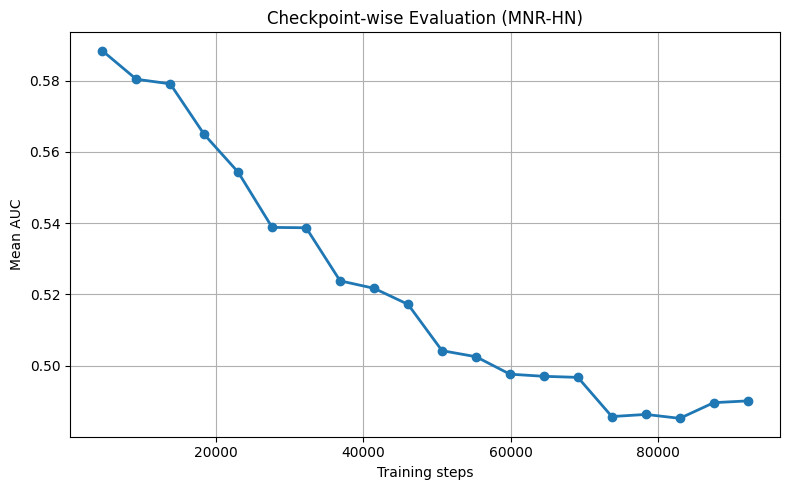

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(steps_hn, mean_auc_hn, marker="o", linewidth=2)

plt.xlabel("Training steps")
plt.ylabel("Mean AUC")
plt.title("Checkpoint-wise Evaluation (MNR-HN)")
plt.grid(True)

plt.tight_layout()
plt.show()


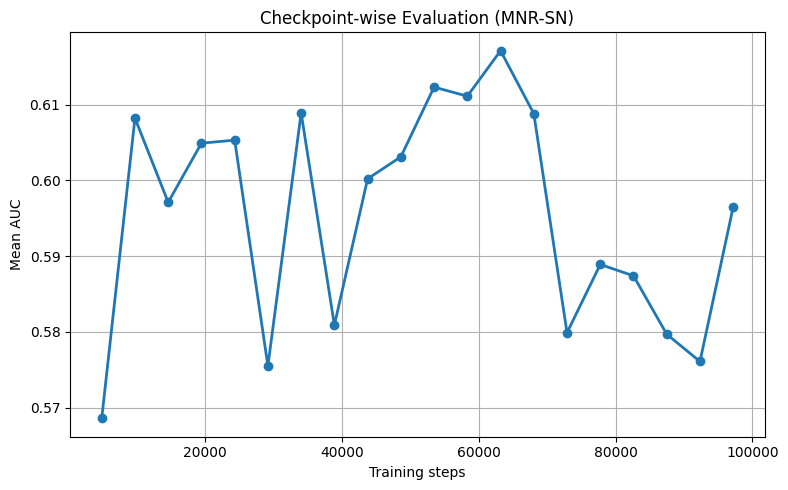

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(steps_sn, mean_auc_sn, marker="o", linewidth=2)

plt.xlabel("Training steps")
plt.ylabel("Mean AUC")
plt.title("Checkpoint-wise Evaluation (MNR-SN)")
plt.grid(True)

plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (20,) and (1,)

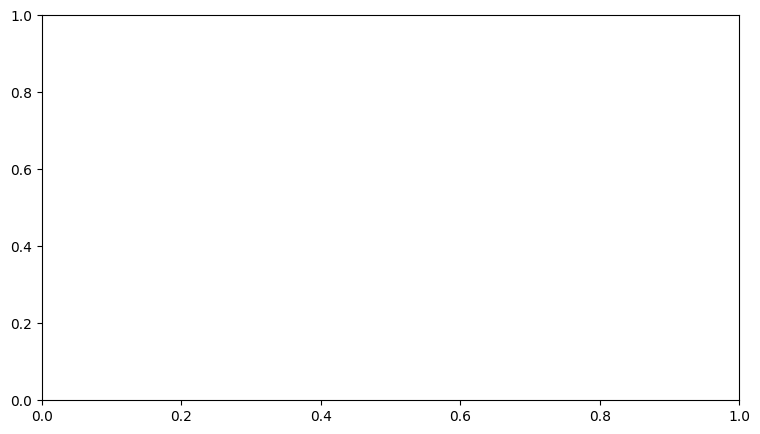

In [15]:
# SN 側（前に使ったもの）
steps_sn = steps
mean_auc_sn = mean_auc

plt.figure(figsize=(9, 5))

plt.plot(steps_sn, mean_auc_sn, marker="o", linewidth=2, label="MNR-SN")
plt.plot(steps_hn, mean_auc_hn, marker="s", linewidth=2, label="MNR-HN")

plt.xlabel("Training steps")
plt.ylabel("Mean AUC")
plt.title("Checkpoint-wise Evaluation: SN vs HN")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [4]:
import re

results = []  # [(step, mean_auc)]

for model_path, mean_auc, _ in model_path_list:
    m = re.search(r"checkpoint-(\d+)", model_path)
    if m:
        step = int(m.group(1))
        results.append((step, mean_auc))

results.sort(key=lambda x: x[0])


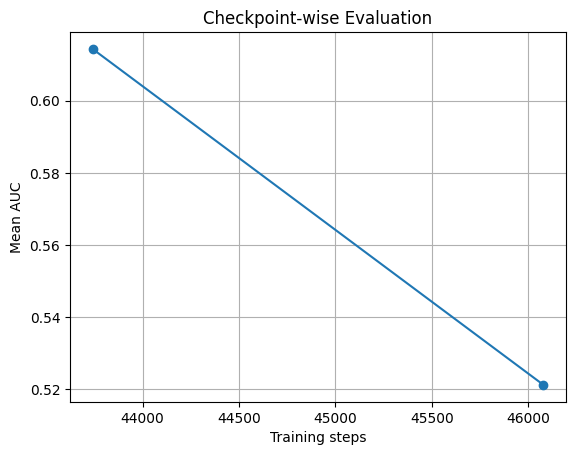

In [6]:
import matplotlib.pyplot as plt
steps = [r[0] for r in results]
aucs  = [r[1] for r in results]

plt.plot(steps, aucs, marker="o")
plt.xlabel("Training steps")
plt.ylabel("Mean AUC")
plt.title("Checkpoint-wise Evaluation")
plt.grid(True)
plt.show()


In [1]:
from ranking_eval import RankingEvaluator
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, models
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers import models, losses, datasets
import json
import os

ranking_hyoka_dataset = "../../resources/dataset/ranking_eval/sho_ranking.json"
dir = "./eval_result/"

model_path_list = [
    ["../sbert_train/jmedroberta_mnr_hn"],
    ["../sbert_train/jmedroberta_mnr_sn"],
    ["../bert_pretrain/jmedroberta_noexpansion"],
    ["../bert_finetune/jmedroberta_livedoor/run-9"],
    ["../bert_finetune/jmedroberta_tmclinical/run-9"],
    ["../bert_finetune/jmedroberta_tmnormal/run-9"],
    ["../bert_preprocess/jmedroberta_bf_randinit"],
    ["../sbert_train/jmedroberta_mnr_hn_c/checkpoint-46080"],
    ["../sbert_train/jmedroberta_mnr_sn_c/checkpoint-43740"],
    ["../sbert_train/jmedroberta_mnr_sn_20"],
    ["../sbert_train/jmedroberta_mnr_hn_20"]
]

"""model_path_list = [
    ["../bert_finetune/jmedroberta_tmclinical/run-0"],
   ["../bert_finetune/jmedroberta_tmclinical/run-1"],
    ["../bert_finetune/jmedroberta_tmclinical/run-2"],
    ["../bert_finetune/jmedroberta_tmclinical/run-3"],
    ["../bert_finetune/jmedroberta_tmclinical/run-4"],
    ["../bert_finetune/jmedroberta_tmclinical/run-5"],
    ["../bert_finetune/jmedroberta_tmclinical/run-6"],
    ["../bert_finetune/jmedroberta_tmclinical/run-7"],
    ["../bert_finetune/jmedroberta_tmclinical/run-8"],
    ["../bert_finetune/jmedroberta_tmclinical/run-9"]
]"""

#model_path_list.sort(reverse=True, key=lambda x: x[1])

with open("./word2vec_score.json", mode="r", encoding="utf-8") as fp:
    w2v_score = json.load(fp)

with open("./tf_idf_score.json", mode="r", encoding="utf-8") as fp:
    tfidf_score = json.load(fp)

def calculate_map(scores_dict):
    ap_values = [score['average_precision'] for score in scores_dict.values()]
    return sum(ap_values) / len(ap_values) if ap_values else 0

score_dict = {}
evaluator = RankingEvaluator(ranking_hyoka_dataset)

for i in range(len(model_path_list)):
    model_path = model_path_list[i][0]
    word_embedding_model = models.Transformer(model_path)
    pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension(),
                                pooling_mode_mean_tokens=True,
                                pooling_mode_cls_token=False,
                                pooling_mode_max_tokens=False)

    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])
    score = evaluator.run_eval(model, output_path=model_path.replace(".", "").replace("/", ""))
    itemnum = 0
    average_num = 0.0
    auc_dict = {}
    print(f"{model_path}: {calculate_map(score)}")
    for q, v in score.items():
        itemnum = itemnum + 1
        average_num = average_num + v['auc']
        auc_dict[q] = v['auc']
    average_num /= itemnum
    model_path_list[i].append(average_num)
    model_path_list[i].append(auc_dict)
    score_dict[model_path] = score


baseline_scores = [(w2v_score, "word2vec"), (tfidf_score, "tf-idf")]

for score, name in baseline_scores:
    itemnum = 0
    average_num = 0.0
    auc_dict = {}
    for q, v in score.items():
        itemnum = itemnum + 1
        average_num = average_num + v['auc']
        auc_dict[q] = v['auc']
    average_num /= itemnum
    print(f"{name} mean auc: {average_num}")


score_dict["word2vec"] = w2v_score
score_dict["tf-idf"] = tfidf_score

name = "all"
# save_graph(score_dict, dir, name)

with open(f"{os.path.join(dir, name)}.json", mode="w", encoding="utf-8") as fp:
    json.dump(score_dict, fp, ensure_ascii=False)


"""model_path_list.sort(reverse=True, key=lambda x: x[2])
for item in model_path_list:
    print(item)"""

model_path_list = [x for x in model_path_list if len(x) >= 2]

model_path_list.sort(key=lambda x: x[1], reverse=True)

for item in model_path_list:
    print(f"model={item[0]}, mean_auc={item[1]}")


with open(f"{os.path.join(dir, name)}_score_list.json", mode="w", encoding="utf-8") as fp:
    json.dump(model_path_list, fp, ensure_ascii=False)

/home/itohiroki/kubert/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


../sbert_train/jmedroberta_mnr_hn: 0.5724528957395186


Some weights of BertModel were not initialized from the model checkpoint at ../bert_pretrain/jmedroberta_noexpansion and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


../sbert_train/jmedroberta_mnr_sn: 0.6845076119074969
../bert_pretrain/jmedroberta_noexpansion: 0.5173039196499485
../bert_finetune/jmedroberta_livedoor/run-9: 0.26293104419994706
../bert_finetune/jmedroberta_tmclinical/run-9: 0.3634030633071217
../bert_finetune/jmedroberta_tmnormal/run-9: 0.29111201558656546
../bert_preprocess/jmedroberta_bf_randinit: 0.4383214606906164
../sbert_train/jmedroberta_mnr_hn_c/checkpoint-46080: 0.5869804367990119
../sbert_train/jmedroberta_mnr_sn_c/checkpoint-43740: 0.6816552435940646
../sbert_train/jmedroberta_mnr_sn_20: 0.6464816553180481
../sbert_train/jmedroberta_mnr_hn_20: 0.6076987746520324
word2vec mean auc: 0.3719494978721375
tf-idf mean auc: 0.5061301374964284
model=../sbert_train/jmedroberta_mnr_sn, mean_auc=0.6182122842535167
model=../sbert_train/jmedroberta_mnr_sn_c/checkpoint-43740, mean_auc=0.6143609616462684
model=../sbert_train/jmedroberta_mnr_sn_20, mean_auc=0.5760775052735629
model=../sbert_train/jmedroberta_mnr_hn_20, mean_auc=0.53868215

Sentence-BERT改善案

In [21]:
from ranking_eval import RankingEvaluator
from sentence_transformers import SentenceTransformer, models
import json
import os

# =========================
# 設定
# =========================
ranking_hyoka_dataset = "../../resources/dataset/ranking_eval/sho_ranking.json"
output_dir = "./eval_result/"
os.makedirs(output_dir, exist_ok=True)

model_path_list = [
    ["../sbert_train/jmedroberta_mnr_hn"],
    ["../sbert_train/jmedroberta_mnr_sn"],
    ["../bert_pretrainjmaedroberta_noexpansion"]
]

# ベースライン
with open("./word2vec_score.json", encoding="utf-8") as fp:
    w2v_score = json.load(fp)

with open("./tf_idf_score.json", encoding="utf-8") as fp:
    tfidf_score = json.load(fp)

# =========================
# 指標計算関数
# =========================
def calculate_mean_auc(score_dict):
    aucs = [v["auc"] for v in score_dict.values()]
    return sum(aucs) / len(aucs) if aucs else 0.0

def calculate_map(score_dict):
    aps = [v["average_precision"] for v in score_dict.values()]
    return sum(aps) / len(aps) if aps else 0.0

# =========================
# 評価
# =========================
evaluator = RankingEvaluator(ranking_hyoka_dataset)

all_results = {}          
summary_list = []         

for model_info in model_path_list:
    model_path = model_info[0]

    word_embedding_model = models.Transformer(model_path)
    pooling_model = models.Pooling(
        word_embedding_model.get_word_embedding_dimension(),
        pooling_mode_mean_tokens=True,
        pooling_mode_cls_token=False,
        pooling_mode_max_tokens=False
    )

    model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

    score = evaluator.run_eval(
        model,
        output_path=model_path.replace(".", "").replace("/", "")
    )

    mean_auc = calculate_mean_auc(score)
    mean_map = calculate_map(score)

    print(f"[MODEL] {model_path}")
    print(f"  mean AUC : {mean_auc:.4f}")
    print(f"  MAP      : {mean_map:.4f}")

    all_results[model_path] = {
        "per_query": score,
        "mean_auc": mean_auc,
        "mean_map": mean_map
    }

    summary_list.append({
        "model": model_path,
        "mean_auc": mean_auc,
        "mean_map": mean_map
    })

# =========================
# ベースライン評価
# =========================
for baseline_score, name in [(w2v_score, "word2vec"), (tfidf_score, "tf-idf")]:
    mean_auc = calculate_mean_auc(baseline_score)
    mean_map = calculate_map(baseline_score)

    print(f"[BASELINE] {name}")
    print(f"  mean AUC : {mean_auc:.4f}")
    print(f"  MAP      : {mean_map:.4f}")

    all_results[name] = {
        "per_query": baseline_score,
        "mean_auc": mean_auc,
        "mean_map": mean_map
    }

    summary_list.append({
        "model": name,
        "mean_auc": mean_auc,
        "mean_map": mean_map
    })

# =========================
# 保存
# =========================
with open(os.path.join(output_dir, "all_results.json"), "w", encoding="utf-8") as fp:
    json.dump(all_results, fp, ensure_ascii=False, indent=2)

# AUCでソート
summary_list.sort(key=lambda x: x["mean_auc"], reverse=True)

with open(os.path.join(output_dir, "summary_by_mean_auc.json"), "w", encoding="utf-8") as fp:
    json.dump(summary_list, fp, ensure_ascii=False, indent=2)

print("\n=== Ranking by mean AUC ===")
for item in summary_list:
    print(f'{item["model"]}: mean_auc={item["mean_auc"]:.4f}, MAP={item["mean_map"]:.4f}')


[MODEL] ../sbert_train/jmedroberta_mnr_hn
  mean AUC : 0.5059
  MAP      : 0.5725
[MODEL] ../sbert_train/jmedroberta_mnr_sn
  mean AUC : 0.6182
  MAP      : 0.6845


HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: '../bert_pretrainjmaedroberta_noexpansion'.

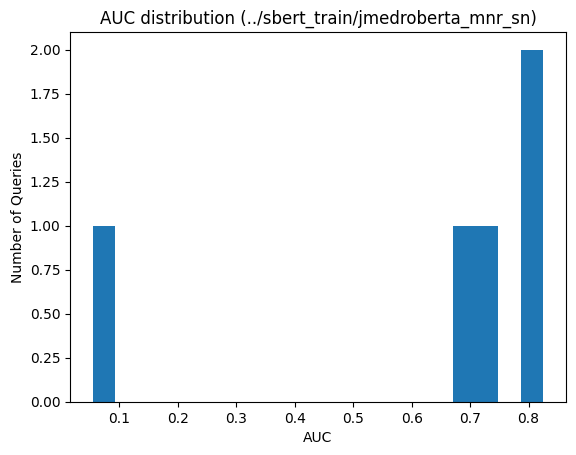

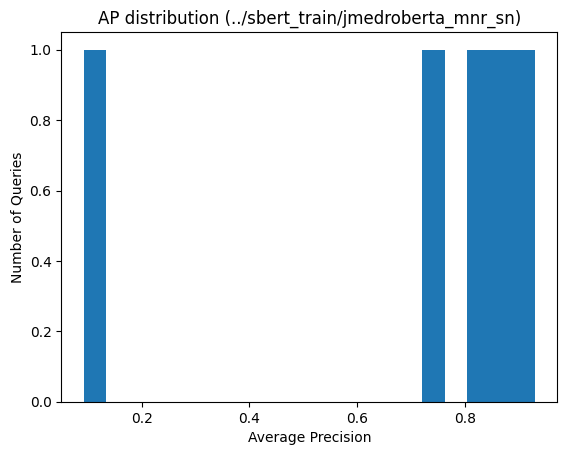

In [16]:
import json
import matplotlib.pyplot as plt

# ===== 設定 =====
json_path = "./eval_result/all.json"
model_name = "../sbert_train/jmedroberta_mnr_sn"

# ===== 読み込み =====
with open(json_path, "r", encoding="utf-8") as f:
    score_dict = json.load(f)

scores = score_dict[model_name]

auc_list = [v["auc"] for v in scores.values()]
ap_list  = [v["average_precision"] for v in scores.values()]

# ===== AUC =====
plt.figure()
plt.hist(auc_list, bins=20)
plt.xlabel("AUC")
plt.ylabel("Number of Queries")
plt.title(f"AUC distribution ({model_name})")
plt.show()

# ===== AP =====
plt.figure()
plt.hist(ap_list, bins=20)
plt.xlabel("Average Precision")
plt.ylabel("Number of Queries")
plt.title(f"AP distribution ({model_name})")
plt.show()


/tmp/ipykernel_3147570/410904825.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(auc_values, labels=models, showfliers=False)


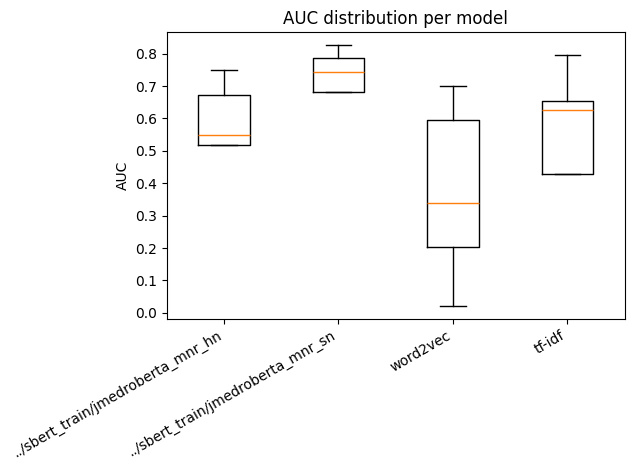

/tmp/ipykernel_3147570/410904825.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ap_values, labels=models, showfliers=False)


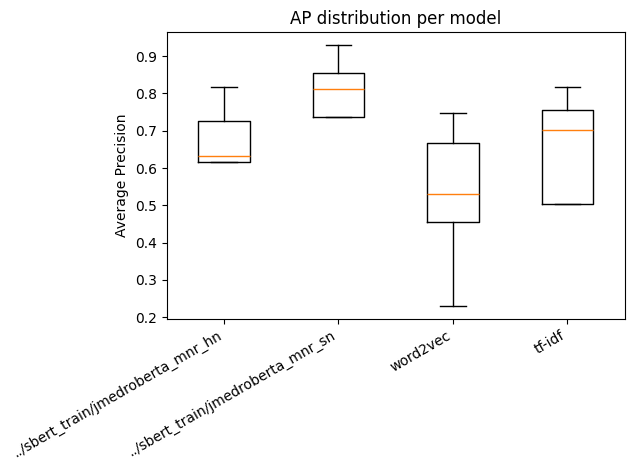

In [17]:
import json
import matplotlib.pyplot as plt

json_path = "./eval_result/all.json"

with open(json_path, "r", encoding="utf-8") as f:
    score_dict = json.load(f)

models = []
auc_values = []
ap_values = []

for model, scores in score_dict.items():
    models.append(model)
    auc_values.append([v["auc"] for v in scores.values()])
    ap_values.append([v["average_precision"] for v in scores.values()])

# ===== AUC =====
plt.figure()
plt.boxplot(auc_values, labels=models, showfliers=False)
plt.xticks(rotation=30, ha="right")
plt.ylabel("AUC")
plt.title("AUC distribution per model")
plt.tight_layout()
plt.show()

# ===== AP =====
plt.figure()
plt.boxplot(ap_values, labels=models, showfliers=False)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Average Precision")
plt.title("AP distribution per model")
plt.tight_layout()
plt.show()


In [ ]:
def get_recall_at_k(model_score, k):
    for query, scores in model_score.items():
        print(f"{query}\trecall@{k}={scores['recall'][k-1]}")

for modelname, model_score in score_dict.items():
    print(f"{modelname}-----------")
    get_recall_at_k(model_score, 1)
    get_recall_at_k(model_score, 5)
    get_recall_at_k(model_score, 10)
    print("---")


In [ ]:
# recall_score_dict = {}
# for key, scores in score_dict.items():
#     recall_score_dict[key] = {}
#     for query, item in scores.items():
#         recall_score_dict[key][query] = item["recall"]
    

# from draw_recallatk_graph import save_graph

# save_graph(recall_score_dict,  dir, name)

In [ ]:
def get_ap_and_map(model_score):
    mean_ap = 0.0
    q_num = 0
    for query, scores in model_score.items():
        q_num += 1
        mean_ap += scores['average_precision']
        print(f"{query}\tAP={scores['average_precision']}")
    print(f"MAP={mean_ap / q_num}")

def get_smooth_map(model_score):
    mean_ap = 0.0
    q_num = 0
    for query, scores in model_score.items():
        if query == "出血":
            continue
        q_num += 1
        mean_ap += scores['average_precision']
    print(f"Smooth MAP={mean_ap / q_num}")

for modelname, model_score in score_dict.items():
    print(f"{modelname}-----------")
    get_ap_and_map(model_score)
    get_smooth_map(model_score)
    print("---")

In [20]:
query = "出血"  
model_name = "../sbert_train/jmedroberta_mnr_sn"

p = data[model_name][query]["precision"]
r = data[model_name][query]["recall"]

plt.figure()
plt.plot(r, p, marker="o")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve ({model_name}, query={query})")
plt.grid(True)
plt.show()


NameError: name 'data' is not defined